In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")

MODEL_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "july2018_model_dataset.nc"
)

LABEL_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "july2018_regime_labels.csv"
)

LABELED_DATASET_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "july2018_regime_labeled_dataset.nc"
)


with xr.open_dataset(MODEL_FILE) as ds:
    model_ds = ds.load()

print(model_ds)

<xarray.Dataset> Size: 15MB
Dimensions:         (date: 31, latitude: 129, longitude: 121)
Coordinates:
  * date            (date) datetime64[ns] 248B 2018-07-01 ... 2018-07-31
  * latitude        (latitude) float64 1kB 6.0 6.25 6.5 6.75 ... 37.5 37.75 38.0
  * longitude       (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
Data variables:
    gefs_rainfall   (date, latitude, longitude) float32 2MB 1.91 1.21 ... 1.35
    imerg_rainfall  (date, latitude, longitude) float32 2MB nan nan ... nan nan
    forecast_error  (date, latitude, longitude) float32 2MB nan nan ... nan nan
    mslp            (date, latitude, longitude) float32 2MB 1.008e+03 ... 1.0...
    u850            (date, latitude, longitude) float32 2MB 9.131 ... -7.654
    v850            (date, latitude, longitude) float32 2MB 0.6757 ... -1.168
    q850            (date, latitude, longitude) float32 2MB 10.48 ... 21.09
    wind_speed_850  (date, latitude, longitude) float32 2MB 9.156 9.58 ... 7.742
Attributes:
  

In [2]:
missing_rows = []

for variable in model_ds.data_vars:
    field = model_ds[variable]

    missing_count = int(
        field.isnull().sum()
    )

    missing_percentage = (
        missing_count / field.size
    ) * 100

    missing_rows.append({
        "variable": variable,
        "missing_count": missing_count,
        "missing_percentage": missing_percentage
    })


missing_df = pd.DataFrame(
    missing_rows
)

missing_df

,variable,missing_count,missing_percentage
0,gefs_rainfall,0,0.000000
1,imerg_rainfall,15376,3.177654
2,forecast_error,15376,3.177654
3,mslp,0,0.000000
4,u850,0,0.000000
5,v850,0,0.000000
6,q850,0,0.000000
7,wind_speed_850,0,0.000000


In [3]:
def region_mean(
    field,
    south,
    north,
    west,
    east
):
    region = field.sel(
        latitude=slice(south, north),
        longitude=slice(west, east)
    )

    return float(
        region.mean(skipna=True)
    )


def region_minimum(
    field,
    south,
    north,
    west,
    east
):
    region = field.sel(
        latitude=slice(south, north),
        longitude=slice(west, east)
    )

    return float(
        region.min(skipna=True)
    )

In [4]:
index_rows = []


for date in model_ds.date.values:
    daily = model_ds.sel(date=date)

    index_rows.append({
        "date": pd.Timestamp(date),

        # Central-India observed rainfall index.
        "central_imerg_rain": region_mean(
            daily["imerg_rainfall"],
            south=18,
            north=28,
            west=73,
            east=88
        ),

        "central_gefs_rain": region_mean(
            daily["gefs_rainfall"],
            south=18,
            north=28,
            west=73,
            east=88
        ),

        # Low-pressure search region.
        "regional_min_mslp": region_minimum(
            daily["mslp"],
            south=15,
            north=25,
            west=75,
            east=92
        ),

        "regional_mean_mslp": region_mean(
            daily["mslp"],
            south=15,
            north=25,
            west=75,
            east=92
        ),

        # Moisture and circulation indices.
        "monsoon_q850": region_mean(
            daily["q850"],
            south=8,
            north=30,
            west=68,
            east=95
        ),

        "monsoon_wind_speed": region_mean(
            daily["wind_speed_850"],
            south=8,
            north=30,
            west=68,
            east=95
        ),

        "arabian_sea_u850": region_mean(
            daily["u850"],
            south=8,
            north=18,
            west=68,
            east=75
        )
    })


regime_indices_df = pd.DataFrame(
    index_rows
)

regime_indices_df

,date,central_imerg_rain,central_gefs_rain,regional_min_mslp,regional_mean_mslp,monsoon_q850,monsoon_wind_speed,arabian_sea_u850
0,2018-07-01,10.901640,15.881274,995.674072,1002.173035,13.751263,7.687492,9.967383
1,2018-07-02,9.204781,18.902895,996.539307,1001.525024,13.770020,9.217375,10.330501
2,2018-07-03,7.498574,16.529045,994.689636,1001.065369,13.787773,10.494304,11.902453
3,2018-07-04,9.863078,17.608206,993.272400,1000.943787,13.743759,10.911782,14.165529
4,2018-07-05,7.192679,14.659368,995.724976,1000.997070,13.759181,9.303931,14.217275
5,2018-07-06,10.633313,11.705813,994.037476,999.514160,13.685947,9.003320,12.732031
6,2018-07-07,9.427863,12.552258,993.251160,998.214111,13.961551,9.655787,15.279474
7,2018-07-08,10.041058,13.490479,991.349304,997.720642,14.119199,9.981433,14.631569
8,2018-07-09,12.009035,13.440077,992.497009,998.074768,14.204325,10.407543,15.433242
9,2018-07-10,11.211820,17.354198,992.967102,998.756958,14.301035,11.118353,17.635359


In [5]:
thresholds = {
    "active_rain": regime_indices_df[
        "central_imerg_rain"
    ].quantile(0.70),

    "break_rain": regime_indices_df[
        "central_imerg_rain"
    ].quantile(0.30),

    "low_pressure": regime_indices_df[
        "regional_min_mslp"
    ].quantile(0.20),

    "strong_wind": regime_indices_df[
        "monsoon_wind_speed"
    ].quantile(0.50)
}


for name, value in thresholds.items():
    print(name, ":", round(value, 3))

active_rain : 15.32
break_rain : 9.863
low_pressure : 991.173
strong_wind : 10.494


In [6]:
def assign_regime(row):
    # Low-pressure systems receive priority.
    if (
        row["regional_min_mslp"]
        <= thresholds["low_pressure"]
        and row["monsoon_wind_speed"]
        >= thresholds["strong_wind"]
    ):
        return "Low/Depression"

    if (
        row["central_imerg_rain"]
        >= thresholds["active_rain"]
    ):
        return "Active"

    if (
        row["central_imerg_rain"]
        <= thresholds["break_rain"]
    ):
        return "Break"

    return "Normal"


regime_indices_df["prototype_regime"] = (
    regime_indices_df.apply(
        assign_regime,
        axis=1
    )
)

regime_indices_df[
    [
        "date",
        "central_imerg_rain",
        "regional_min_mslp",
        "monsoon_wind_speed",
        "prototype_regime"
    ]
]

,date,central_imerg_rain,regional_min_mslp,monsoon_wind_speed,prototype_regime
0,2018-07-01,10.901640,995.674072,7.687492,Normal
1,2018-07-02,9.204781,996.539307,9.217375,Break
2,2018-07-03,7.498574,994.689636,10.494304,Break
3,2018-07-04,9.863078,993.272400,10.911782,Break
4,2018-07-05,7.192679,995.724976,9.303931,Break
5,2018-07-06,10.633313,994.037476,9.003320,Normal
6,2018-07-07,9.427863,993.251160,9.655787,Break
7,2018-07-08,10.041058,991.349304,9.981433,Normal
8,2018-07-09,12.009035,992.497009,10.407543,Normal
9,2018-07-10,11.211820,992.967102,11.118353,Normal


In [7]:
regime_counts = (
    regime_indices_df[
        "prototype_regime"
    ]
    .value_counts()
    .rename_axis("regime")
    .reset_index(name="days")
)

regime_counts

,regime,days
0,Normal,11
1,Break,9
2,Low/Depression,7
3,Active,4


In [8]:
small_classes = regime_counts[
    regime_counts["days"] < 2
]

if len(small_classes) > 0:
    print(
        "Warning: Some regimes contain fewer "
        "than two dates."
    )

    display(small_classes)

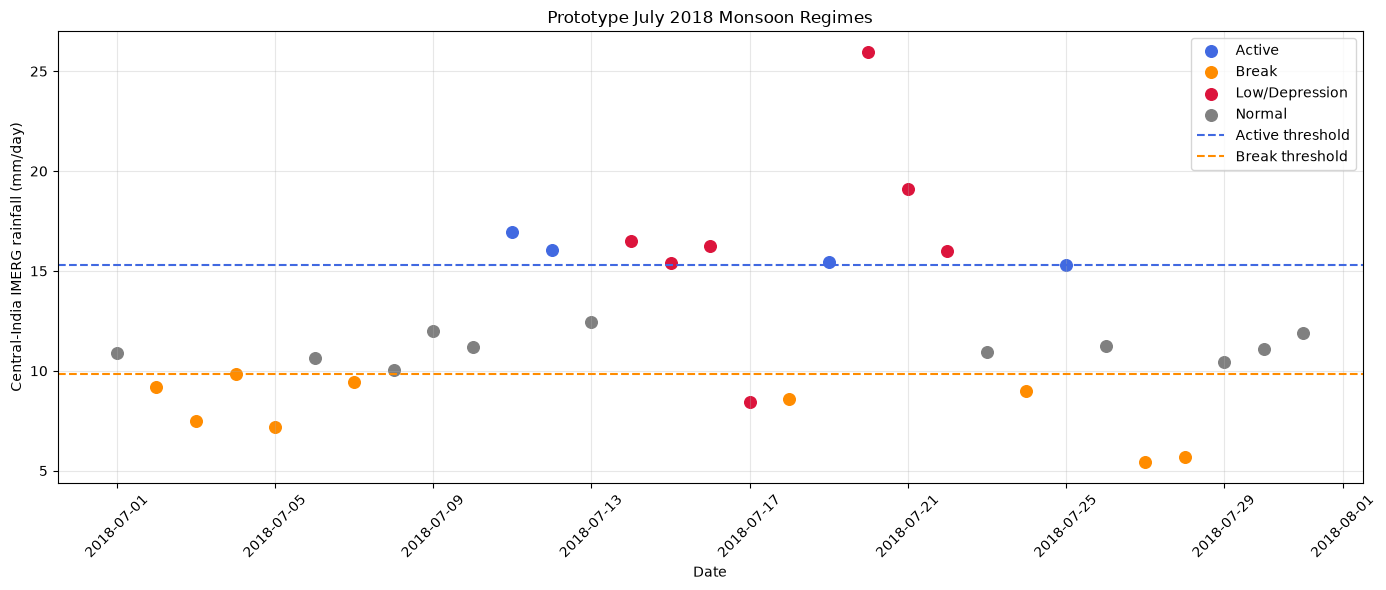

In [9]:
REGIME_COLORS = {
    "Active": "royalblue",
    "Break": "darkorange",
    "Low/Depression": "crimson",
    "Normal": "gray"
}


plt.figure(figsize=(14, 6))

for regime, group in regime_indices_df.groupby(
    "prototype_regime"
):
    plt.scatter(
        group["date"],
        group["central_imerg_rain"],
        color=REGIME_COLORS[regime],
        label=regime,
        s=70
    )

plt.axhline(
    thresholds["active_rain"],
    color="royalblue",
    linestyle="--",
    label="Active threshold"
)

plt.axhline(
    thresholds["break_rain"],
    color="darkorange",
    linestyle="--",
    label="Break threshold"
)

plt.ylabel("Central-India IMERG rainfall (mm/day)")
plt.xlabel("Date")
plt.title("Prototype July 2018 Monsoon Regimes")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
regime_indices_df.to_csv(
    LABEL_FILE,
    index=False
)

print("Saved:", LABEL_FILE.exists())
print("Location:", LABEL_FILE)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\july2018_regime_labels.csv


In [11]:
REGIME_CODES = {
    "Break": 0,
    "Normal": 1,
    "Active": 2,
    "Low/Depression": 3
}


regime_indices_df["regime_code"] = (
    regime_indices_df[
        "prototype_regime"
    ].map(REGIME_CODES)
)


regime_codes = xr.DataArray(
    regime_indices_df[
        "regime_code"
    ].to_numpy(dtype=np.int8),
    coords={
        "date": model_ds.date
    },
    dims="date",
    name="regime_code"
)

regime_codes.attrs = {
    "0": "Break",
    "1": "Normal",
    "2": "Active",
    "3": "Low/Depression",
    "label_type": "prototype hybrid rule-based labels"
}


labeled_ds = model_ds.assign(
    regime_code=regime_codes
)

labeled_ds.attrs.update({
    "regime_labels": "Prototype labels, not official IMD labels",
    "regime_method": (
        "Observed rainfall quantiles plus "
        "forecast pressure and wind indices"
    )
})


labeled_ds.to_netcdf(
    LABELED_DATASET_FILE,
    mode="w",
    engine="netcdf4"
)

print("Saved:", LABELED_DATASET_FILE.exists())
print("Location:", LABELED_DATASET_FILE)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\july2018_regime_labeled_dataset.nc
